# Vectorized Records Matching

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## Import and Transform Mentions Data

The data required some regex massaging from the SQL prior to importing.

In [287]:
# Read file
cols = ["mention_id",   "source",   "source_year",  "county",   "original_data",    "confidence",   "full_name",    "first_name",   "middle_name",  "last_name",    "maiden_name",  "birth_year",   "death_year",   "race", "gender",   "occupation",   "legal_status", "is_enslaver",  "norm_first_name",  "nysiis_last_name", "norm_race",    "norm_occupation",  "enslaver_id",  "location_id",  "head", "household_id", "family_id",    "created",  "narrative"]
MENTION = pd.read_csv("./mentions.csv", sep="\t", header=None, names=cols)

# Remove cruft
for col in MENTION.columns:
    MENTION[col] = MENTION[col].str.replace(r"(^'|'?,$)", "", regex=True)
MENTION = MENTION.replace("NULL", None)

# # Remove unwanted columns
# col_unwanted = ['original_data', 'narrative', 'created', 'household_id']
# for col in col_unwanted:
#     MENTION = MENTION.drop(col, axis=1)

# Set index to ID
MENTION = MENTION.set_index('mention_id')
print("Duplicate indexes?", MENTION.index.has_duplicates)
print("Duplicate data?", MENTION.shape[0] > MENTION.drop_duplicates().shape[0])

# Cast Categorical data
col_cat = ['race', 'norm_race', 'gender', 'occupation', 'norm_occupation', 'legal_status', 'is_enslaver', 'source', 'county']
for col in col_cat:
    MENTION[col] = MENTION[col].fillna('_').str.replace(r"^\s*$", "_", regex=True)
    MENTION[col] = MENTION[col].astype('category')
CATS = pd.concat([MENTION[col].value_counts().to_frame('n') for col in col_cat], keys=col_cat)

# Cast Integer data
col_int = ['birth_year', 'source_year']
for col in col_int:
    MENTION[col] = MENTION[col].str.replace(r"^\s*$", "-1", regex=True)
    MENTION[col] = MENTION[col].fillna(-1).astype(int)

## Select cols for linkage
col_link = ['full_name', 'birth_year', 'norm_race', 'gender', 'norm_occupation', 'legal_status', 'head', 'enslaver_id']

## Apply OHCO
ohco = ['birth_year','legal_status','norm_race','gender', 'full_name']
print("Blocking cols:", ohco)
M = MENTION[col_link].set_index(ohco).sort_index().copy()
# MENTION_TYPES = MENTION_TOKENS.value_counts(ohco).to_frame('n').sort_index()

M.sample(10)

Duplicate indexes? False
Duplicate data? False
Blocking cols: ['birth_year', 'legal_status', 'norm_race', 'gender', 'full_name']


,,,,,norm_occupation,head,enslaver_id
birth_year,legal_status,norm_race,gender,full_name,,,
1845,F,W,F,Mary Martin,DOMESTIC,f,None
1854,F,B,F,Rachel Coles,_,f,None
1866,F,B,F,Anna Moss,_,f,None
1832,F,W,M,J N Thomas,_,t,None
1800,F,B,F,Matilda Minor,DOMESTIC,f,None
-1,_,_,F,Rose Jones,_,None,None
1809,F,W,M,John C Fitz,AGRICULTURE,t,None
-1,_,_,F,Maria?,_,None,None
1848,F,B,M,Jac Harris,_,f,None


In [273]:
MENTION.source.value_counts()

source
ALB_CN_1880       32415
ALB_VR_1715       23388
ALB_CN_1870       22587
ALB_SS-1860       15693
ALB_SS-1850       14054
ALB_FBR            2489
ALB_FindAGrave     1611
ALB_FL-1865         688
Name: count, dtype: int64

In [274]:
BLACK = M.value_counts(['birth_year','norm_race','gender','full_name'])\
    .to_frame('n_recs')\
    .query("n_recs > 0 & full_name != '' & birth_year >= 1800 & norm_race == 'B'")\
    .sort_index()
BLACK.sample(10)

n_recs
birth_year norm_race gender full_name                
1859       B         M      Robert                  2
1851       B         F      Willie Ann Harris       1
1866       B         M      Jack Dickerson          1
                     F      Martha A Simons         1
1877       B         F      Anna                    1
1832       B         F      Marget Johnson          1
1853       B         M      Wilson Terrill          1
1859       B         M      Charles                 2
1840       B         M      Hodge Howard            1
1847       B         F      Gillie AC Barnett       1

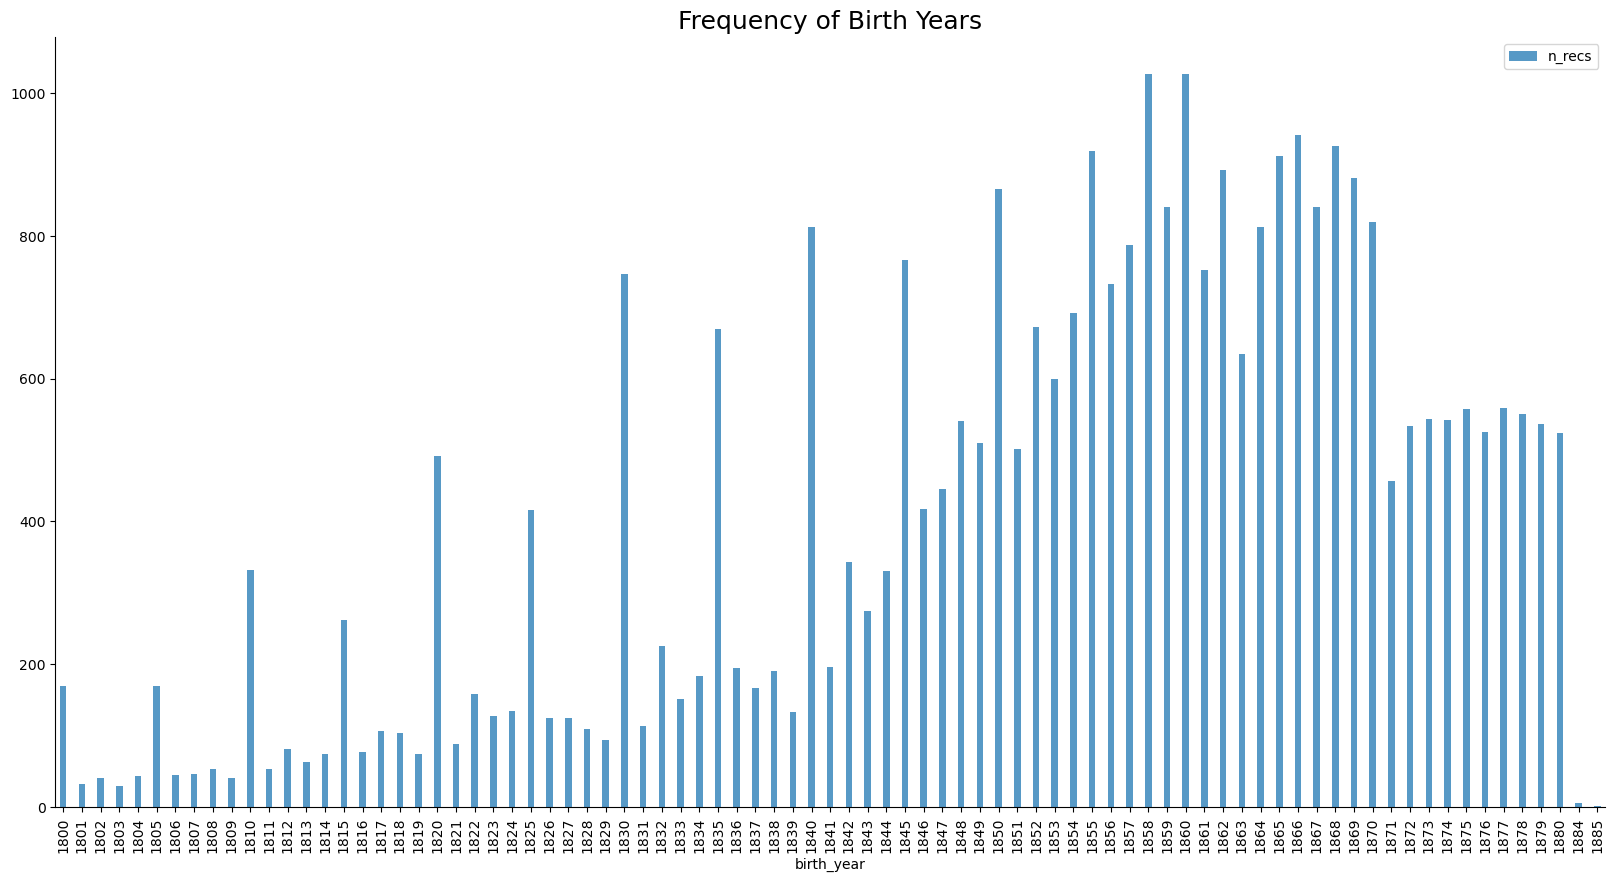

In [275]:
BLACK.groupby('birth_year', observed=True).count().plot.bar(width=.35, alpha=.75, figsize=(20,10))
sns.despine()
plt.title("Frequency of Birth Years", fontsize=18)
plt.show()

## Save

In [181]:
MENTION.to_parquet("MENTION.parquet", index=True)
M.to_parquet("M.parquet", index=True)